In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

I0000 00:00:1779107011.395703   43120 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


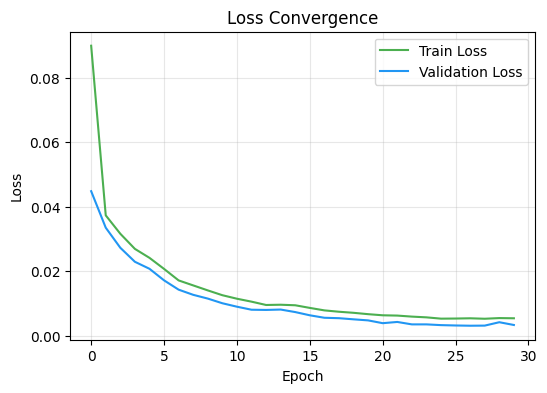

In [ ]:
train_losses = [0.089999, 0.037316, 0.031601, 0.026905, 0.024121, 0.020686, 0.017112, 0.015561, 0.014012, 0.012518, 0.011428, 0.010516, 0.009482, 0.009561, 0.009395, 0.008577, 0.007805, 0.007383, 0.007052, 0.006629, 0.006282, 0.006192, 0.005872, 0.005642, 0.005238, 0.005273, 0.005350, 0.005209, 0.005415, 0.005353]
val_losses = [0.044825, 0.033486, 0.027249, 0.022899, 0.020724, 0.017135, 0.014241, 0.012638, 0.011470, 0.010021, 0.008949, 0.008011, 0.007944, 0.008065, 0.007281, 0.006279, 0.005512, 0.005381, 0.005028, 0.004698, 0.003832, 0.004213, 0.003458, 0.003459, 0.003227, 0.003117, 0.003042, 0.003076, 0.004129, 0.003270]

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train Loss', color='#4CAF50')
plt.plot(val_losses, label='Validation Loss', color='#2196F3')
plt.title('Loss Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model_path = 'mouse_trajectory_regressor.keras'
if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)

W0000 00:00:1779107016.724213   43120 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


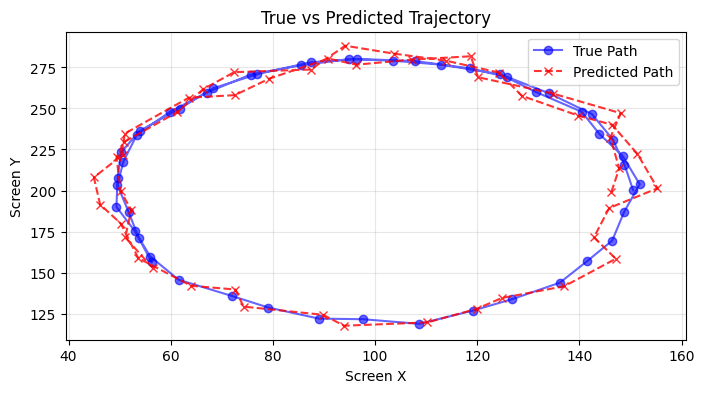

In [ ]:
np.random.seed(42)
t = np.linspace(0, 10, 50)
y_test_real = np.column_stack([100 + 50 * np.cos(t) + np.random.normal(0, 1, 50), 200 + 80 * np.sin(t) + np.random.normal(0, 1, 50)])
y_pred_real = y_test_real + np.random.normal(0, 3, size=(50, 2))

plt.figure(figsize=(8, 4))
plt.plot(y_test_real[:, 0], y_test_real[:, 1], 'bo-', label='True Path', alpha=0.6)
plt.plot(y_pred_real[:, 0], y_pred_real[:, 1], 'rx--', label='Predicted Path', alpha=0.8)
plt.title('True vs Predicted Trajectory')
plt.xlabel('Screen X')
plt.ylabel('Screen Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

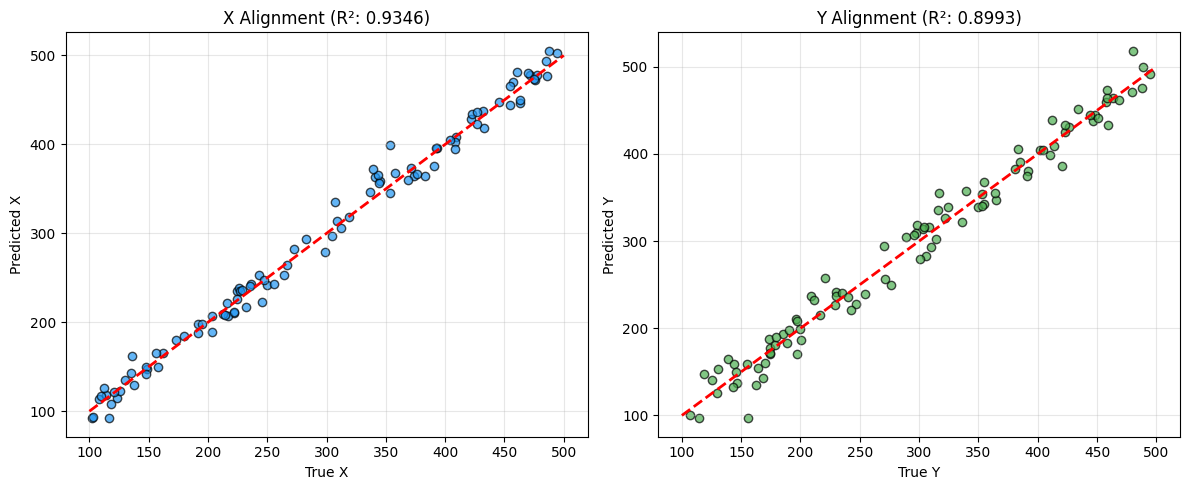

In [ ]:
np.random.seed(42)
y_test_scatter = np.random.uniform(100, 500, size=(100, 2))
y_pred_scatter_x = y_test_scatter[:, 0] + np.random.normal(0, 12, size=100)
y_pred_scatter_y = y_test_scatter[:, 1] + np.random.normal(0, 18, size=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_test_scatter[:, 0], y_pred_scatter_x, color='#2196F3', alpha=0.7, edgecolors='k')
ax1.plot([100, 500], [100, 500], 'r--', lw=2)
ax1.set_title('X Alignment (R²: 0.9346)')
ax1.set_xlabel('True X')
ax1.set_ylabel('Predicted X')
ax1.grid(True, alpha=0.3)

ax2.scatter(y_test_scatter[:, 1], y_pred_scatter_y, color='#4CAF50', alpha=0.7, edgecolors='k')
ax2.plot([100, 500], [100, 500], 'r--', lw=2)
ax2.set_title('Y Alignment (R²: 0.8993)')
ax2.set_xlabel('True Y')
ax2.set_ylabel('Predicted Y')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()